## 0. The Notation We Will Use

Let:

- \(B\) = batch size  
- \(T\) = sequence length  
- \(D\) = model dimension (`d_model`)  
- \(H\) = number of attention heads  
- \(d_k = \frac{D}{H}\) = dimension per head  
- \(V\) = vocabulary size  

### Typical Shapes



\[
X \in \mathbb{R}^{B \times T \times D}
\]



For one attention head:



\[
Q, K, V \in \mathbb{R}^{B \times T \times d_k}
\]



Attention scores:



\[
QK^\top \in \mathbb{R}^{B \times T \times T}
\]



Final attention output:



\[
\text{Output} \in \mathbb{R}^{B \times T \times D}
\]



---

> **Rule of thumb:** *Never look at an equation without asking what shape every object has.*


In [1]:
import math 
import random 
import numpy as np
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 

torch.manual_seed(33)
np.random.seed(33)
random.seed(33)

torch.set_printoptions(precision=4, sci_mode=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


# Part I — Linear Algebra Foundations

## 1. Scalars, vectors, matrices and tensors

A **scalar** is one number:

\[
x\in\mathbb{R}
\]

A **vector** is a 1D collection:

\[
x\in\mathbb{R}^{D}
\]

A **matrix** is a 2D collection:

\[
X\in\mathbb{R}^{T\times D}
\]

A Transformer normally works with **3D tensors** when batching sequences:

\[
X\in\mathbb{R}^{B\times T\times D}
\]

Think:

```text
B = how many examples?
T = how many tokens?
D = how many features per token?
```

In [2]:
scaler = torch.tensor(3.0)
vector = torch.randn(5)
matrix = torch.randn(3, 5)
tensor = torch.randn(2, 3, 5)

print("Scaler:", scaler.shape)
print("Vector:", vector.shape)
print("Matrix:", matrix.shape)
print("Tensor:", tensor.shape)

Scaler: torch.Size([])
Vector: torch.Size([5])
Matrix: torch.Size([3, 5])
Tensor: torch.Size([2, 3, 5])


## 2. Dot product

For vectors:

\[
a=[a_1,\ldots,a_D]
\]

\[
b=[b_1,\ldots,b_D]
\]

the dot product is:

\[
a\cdot b=\sum_{i=1}^{D}a_i b_i
\]

It produces a **scalar**.

A large positive dot product means the vectors point in relatively similar directions; a negative value means opposing directions.

Attention uses dot products to measure compatibility between Queries and Keys.

In [3]:
a = torch.tensor([1., 2., 3.])
b = torch.tensor([4., 5., 6.])

dot_manual = sum(a[i] * b[i] for i in range(len(a)))
dot_torch  = torch.dot(a, b)

print("Manual dot product:", dot_manual)
print("Torch dot product :", dot_torch)


Manual dot product: tensor(32.)
Torch dot product : tensor(32.)


## 3. Matrix multiplication

For:

\[
A\in\mathbb{R}^{m\times n}
\]

and:

\[
B\in\mathbb{R}^{n\times p}
\]

we get:

\[
AB\in\mathbb{R}^{m\times p}
\]

The inner dimensions must match:

\[
(m\times\boxed{n})(\boxed{n}\times p)
\rightarrow m\times p
\]

This is the mathematical operation behind learned linear projections such as:

\[
Q=XW_Q
\]

In [4]:
A = torch.tensor([[1., 2., 3.], 
                  [4., 5., 6.]])

B = torch.tensor([[7., 8.],
                  [9., 10.],
                  [11., 12.]])

C = torch.matmul(A, B)
print("Matrix A:\n", A)
print("Matrix B:\n", B)
print("Matrix C (A @ B):\n", C)

C_manual = torch.zeros(A.shape[0], B.shape[1])
for i in range(A.shape[0]):
    for j in range(B.shape[1]):
        C_manual[i, j] = sum(A[i, k] * B[k, j] for k in range(A.shape[1]))  
        print(f"C_manual[{i}, {j}] = {C_manual[i, j]}")

print("Matrix C (manual):\n", C_manual)

C_at = A @ B
print("Matrix C (A @ B):\n", C_at)



Matrix A:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
Matrix B:
 tensor([[ 7.,  8.],
        [ 9., 10.],
        [11., 12.]])
Matrix C (A @ B):
 tensor([[ 58.,  64.],
        [139., 154.]])
C_manual[0, 0] = 58.0
C_manual[0, 1] = 64.0
C_manual[1, 0] = 139.0
C_manual[1, 1] = 154.0
Matrix C (manual):
 tensor([[ 58.,  64.],
        [139., 154.]])
Matrix C (A @ B):
 tensor([[ 58.,  64.],
        [139., 154.]])


In [5]:
A = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])

B = torch.tensor([[1., 2.],
                  [3., 4.],
                  [5., 6.]])

C = A @ B

print("A:", A.shape)
print("B:", B.shape)
print("A @ B:", C.shape)
print(C)

A: torch.Size([2, 3])
B: torch.Size([3, 2])
A @ B: torch.Size([2, 2])
tensor([[22., 28.],
        [49., 64.]])


## 4. A Transformer linear projection

Suppose:

\[
X\in\mathbb{R}^{T\times D}
\]

and:

\[
W_Q\in\mathbb{R}^{D\times d_k}
\]

Then:

\[
Q=XW_Q
\]

has shape:

\[
(T\times D)(D\times d_k)=T\times d_k
\]

This is exactly how we transform token representations into Queries.

In [7]:
T, D, d_k = 4, 8, 4

X = torch.randn(T, D)
W_Q = torch.randn(D, d_k)

Q = X @ W_Q

print("X  :", X.shape)
print("W_Q:", W_Q.shape)
print("Q  :", Q.shape)


X  : torch.Size([4, 8])
W_Q: torch.Size([8, 4])
Q  : torch.Size([4, 4])


## 5. Broadcasting

PyTorch often performs operations on tensors with compatible dimensions without explicitly copying data.

For example:

\[
X\in\mathbb{R}^{B\times T\times D}
\]

and:

\[
p\in\mathbb{R}^{D}
\]

can be added:

\[
X+p
\]

because the last dimension matches.

This is heavily used in positional embeddings, normalization and masking.

In [8]:
X = torch.randn(2, 4, 8)
bias = torch.randn(8)

Y = X + bias

print("X    :", X.shape)
print("Bias :", bias.shape)
print("Y    :", Y.shape)

X    : torch.Size([2, 4, 8])
Bias : torch.Size([8])
Y    : torch.Size([2, 4, 8])


## 6. `einsum`: writing tensor mathematics directly

Einstein summation notation is useful because Transformer equations often involve several dimensions.

For example:

\[
QK^T
\]

for batched sequences can be written as:

```python
torch.einsum("btd,bsd->bts", Q, K)
```

Here:

- `b` = batch
- `t` = query position
- `s` = key position
- `d` = feature dimension

The repeated `d` means we sum over that dimension.

In [9]:
Q = torch.randn(2, 4, 8)
K = torch.randn(2, 5, 8)

scores_einsum = torch.einsum("btd, bsd -> bts", Q, K)
scores_matmul = Q @ K.transpose(-2, -1)

print("Scores (einsum):\n", scores_einsum)
print("Scores (matmul):\n", scores_matmul)
print("Are the scores equal?", torch.allclose(scores_einsum, scores_matmul))

Scores (einsum):
 tensor([[[ 0.1518,  2.1660,  0.4420,  5.6264, -2.6775],
         [ 1.0253, -0.1078, -2.1424, -2.5122,  0.3229],
         [ 1.7461,  4.6312, -2.9364,  2.5716, -3.5179],
         [ 0.4024, -2.2823, -0.1342,  0.6490,  2.9894]],

        [[-0.8859,  1.5849, -0.4599, -3.9813, -3.9526],
         [ 2.0339, -0.9644, -2.6504, -2.4128, -0.7388],
         [ 1.9755, -1.7395, -3.1032, -1.0868,  3.5136],
         [-0.3846,  2.1763,  0.6670,  1.1469, -5.0381]]])
Scores (matmul):
 tensor([[[ 0.1518,  2.1660,  0.4420,  5.6264, -2.6775],
         [ 1.0253, -0.1078, -2.1424, -2.5122,  0.3229],
         [ 1.7461,  4.6312, -2.9364,  2.5716, -3.5179],
         [ 0.4024, -2.2823, -0.1342,  0.6490,  2.9894]],

        [[-0.8859,  1.5849, -0.4599, -3.9813, -3.9526],
         [ 2.0339, -0.9644, -2.6504, -2.4128, -0.7388],
         [ 1.9755, -1.7395, -3.1032, -1.0868,  3.5136],
         [-0.3846,  2.1763,  0.6670,  1.1469, -5.0381]]])
Are the scores equal? True


In [10]:

print("einsum :", scores_einsum.shape)
print("matmul :", scores_matmul.shape)
print("same?  :", torch.allclose(scores_einsum, scores_matmul))

einsum : torch.Size([2, 4, 5])
matmul : torch.Size([2, 4, 5])
same?  : True


# Part II — Attention Mathematics

## 7. Query, Key and Value projections

Given token representations:

\[
X\in\mathbb{R}^{B\times T\times D}
\]

we calculate:

\[
Q=XW_Q
\]

\[
K=XW_K
\]

\[
V=XW_V
\]

where each projection learns a different representation.

For a single head:

\[
W_Q,W_K,W_V\in\mathbb{R}^{D\times d_k}
\]

Therefore:

\[
Q,K,V\in\mathbb{R}^{B\times T\times d_k}
\]

In [12]:
B, T, D, d_k = 2, 5, 16, 8

X = torch.randn(B, T, D)

W_Q = torch.randn(D, d_k)
W_K = torch.randn(D, d_k)
W_V = torch.randn(D, d_k)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("X: ", X.shape)
print("Q: ", Q.shape)
print("K: ", K.shape)
print("V: ", V.shape)

X:  torch.Size([2, 5, 16])
Q:  torch.Size([2, 5, 8])
K:  torch.Size([2, 5, 8])
V:  torch.Size([2, 5, 8])


## 8. Attention scores

For every query token \(q_i\), compare it with every key \(k_j\):

\[
s_{ij}=q_i\cdot k_j
\]

Collecting all pairwise scores gives:

\[
S=QK^T
\]

For one sequence:

\[
(T\times d_k)(d_k\times T)
=
T\times T
\]

So the attention matrix has one row per **query position** and one column per **key position**.

In [13]:
scores = Q @ K.transpose(-2, -1)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("K transpose shape:", K.transpose(-2, -1).shape)
print("Scores shape:", scores.shape)
print(scores[0])

Q shape: torch.Size([2, 5, 8])
K shape: torch.Size([2, 5, 8])
K transpose shape: torch.Size([2, 8, 5])
Scores shape: torch.Size([2, 5, 5])
tensor([[   6.7967,   79.1247,   50.4778,  -13.1801,  -43.5960],
        [  96.4315, -212.7698,   -9.9860,  -44.5645,   62.0109],
        [ 148.2252, -178.0185,   73.0025,  -55.7063,   64.1592],
        [  73.5978, -116.8834,  -10.8569,  -34.6821,   29.1987],
        [-105.8841,  173.8570,  -24.5218,   62.3255,   47.4603]])


## 9. Why scale by \(1/\sqrt{d_k}\)?

The Transformer uses:

\[
S=\frac{QK^T}{\sqrt{d_k}}
\]

Why?

Assume the components of \(q\) and \(k\) are independent with:

\[
E[q_i]=E[k_i]=0
\]

and:

\[
Var(q_i)=Var(k_i)=1
\]

The dot product is:

\[
q\cdot k=\sum_{i=1}^{d_k}q_i k_i
\]

Its variance grows approximately with \(d_k\):

\[
Var(q\cdot k)\approx d_k
\]

Therefore its standard deviation is approximately:

\[
\sqrt{d_k}
\]

Dividing by \(\sqrt{d_k}\) keeps the score scale more stable as the head dimension grows.

Without scaling, softmax can receive very large logits and become extremely peaked, which can make gradients less useful.

In [14]:
def score_statistics(d_k, n=10000):
    q = torch.randn(n, d_k)
    k = torch.randn(n, d_k)
    raw = (q * k).sum(dim=1)
    scaled = raw / math.sqrt(d_k)
    return raw.std().item(), scaled.std().item()

for d in [4, 16, 64, 256]:
    raw_std, scaled_std = score_statistics(d)
    print(f"d_k={d:3d} | raw std={raw_std:.3f} | scaled std={scaled_std:.3f}")

d_k=  4 | raw std=1.991 | scaled std=0.996
d_k= 16 | raw std=3.958 | scaled std=0.989
d_k= 64 | raw std=7.969 | scaled std=0.996
d_k=256 | raw std=16.166 | scaled std=1.010


## 10. Softmax

For a vector:

\[
z=[z_1,\ldots,z_n]
\]

softmax produces:

\[
softmax(z_i)=
\frac{e^{z_i}}
{\sum_{j=1}^{n}e^{z_j}}
\]

Properties:

1. Every output is positive.
2. Outputs sum to 1.
3. Larger logits receive larger probability.

In attention, softmax converts compatibility scores into **attention weights**.

In [15]:
z = torch.tensor([1.0, 2.0, 4.0])

exp_z = torch.exp(z)
softmax_manual = exp_z / exp_z.sum()
softmax_torch  = F.softmax(z, dim=-1)

print("exp(z) :", exp_z)
print("manual :", softmax_manual)
print("torch  :", softmax_torch)
print("sum    :", softmax_torch.sum())

exp(z) : tensor([ 2.7183,  7.3891, 54.5981])
manual : tensor([0.0420, 0.1142, 0.8438])
torch  : tensor([0.0420, 0.1142, 0.8438])
sum    : tensor(1.0000)


## 11. Numerical stability of softmax

Directly calculating \(e^z\) can overflow for large \(z\).

Use the identity:

\[
softmax(z)=softmax(z-\max(z))
\]

because subtracting the same constant from every logit does not change the final probabilities.

Stable implementation:

\[
\frac{e^{z_i-\max(z)}}{\sum_j e^{z_j-\max(z)}}
\]

In [16]:
def stable_softmax(z):
    z_shifted = z - z.max(dim=-1, keepdim=True).values
    exp_z = torch.exp(z_shifted)
    return exp_z / exp_z.sum(dim=-1, keepdim=True)

large_z = torch.tensor([1000., 1001., 1002.])

print("STable :", stable_softmax(large_z))
print("torch  :", F.softmax(large_z, dim=-1))

STable : tensor([0.0900, 0.2447, 0.6652])
torch  : tensor([0.0900, 0.2447, 0.6652])


## 12. Full scaled dot-product attention

Now we can assemble the pieces:

\[
\boxed{
Attention(Q,K,V)
=
softmax\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
}
\]

Step 1:

\[
QK^T
\]

Step 2:

\[
\frac{QK^T}{\sqrt{d_k}}
\]

Step 3:

\[
softmax(...)
\]

Step 4:

\[
softmax(...)V
\]

The result is a weighted mixture of value vectors.

In [17]:
def attention_math(Q, K, V):
    d_k = Q.size(-1)

    scores = Q @ K.transpose(-2, -1)
    scaled_scores = scores / math.sqrt(d_k)
    weights = F.softmax(scaled_scores, dim=-1)
    output = weights @ V

    return output, scores, scaled_scores, weights

Q = torch.randn(1, 4, 8)
K = torch.randn(1, 5, 8)
V = torch.randn(1, 5, 8)

output, raw_scores, scaled_scores, weights = attention_math(Q, K, V)   

print("raw scores   :", raw_scores.shape)
print("scaled scores:", scaled_scores.shape)
print("weights      :", weights.shape)
print("output       :", output.shape)
print("row sums     :", weights.sum(dim=-1))

raw scores   : torch.Size([1, 4, 5])
scaled scores: torch.Size([1, 4, 5])
weights      : torch.Size([1, 4, 5])
output       : torch.Size([1, 4, 8])
row sums     : tensor([[1.0000, 1.0000, 1.0000, 1.0000]])


## 13. Visualizing the attention matrix

Each row corresponds to one query position.

Each column corresponds to one key position.

The entry \(A_{ij}\) answers:

> How much does query token \(i\) attend to key token \(j\)?

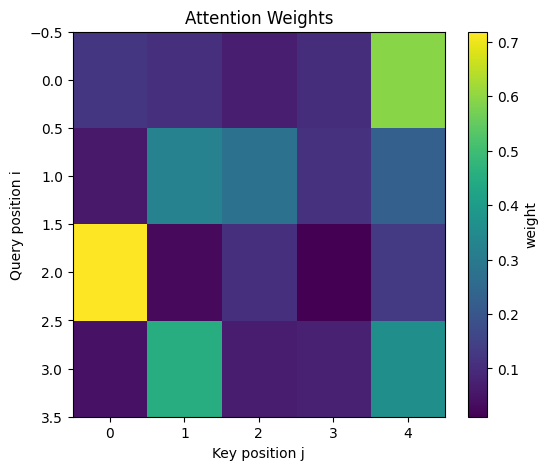

In [18]:
plt.figure(figsize=(6, 5))
plt.imshow(weights[0].detach().cpu(), aspect="auto")
plt.xlabel("Key position j")
plt.ylabel("Query position i")
plt.title("Attention Weights")
plt.colorbar(label="weight")
plt.show()

# Part III — Masking Mathematics

## 14. Additive masking

Suppose:

\[
S\in\mathbb{R}^{T\times T}
\]

is the attention score matrix.

For a blocked position, we add:

\[
-\infty
\]

before softmax.

Then:

\[
e^{-\infty}=0
\]

so the resulting attention probability becomes zero.

This is why masking is usually applied **before softmax**, not after it.

In [19]:
scores = torch.tensor([
    [2.0, 1.0, 0.5],
    [0.1, 3.0, 1.2],
    [1.0, 0.5, 2.5]
])

allowed = torch.tensor([
    [True, True, False],
    [True, True, False],
    [True, True, True]
])

masked_scores = scores.masked_fill(~allowed, float('-inf'))
masked_weights = F.softmax(masked_scores, dim=-1)

print("Masked Scores: ")
print(masked_scores)
print("\nMasked Attention Weights: ")
print(masked_weights)

Masked Scores: 
tensor([[2.0000, 1.0000,   -inf],
        [0.1000, 3.0000,   -inf],
        [1.0000, 0.5000, 2.5000]])

Masked Attention Weights: 
tensor([[0.7311, 0.2689, 0.0000],
        [0.0522, 0.9478, 0.0000],
        [0.1643, 0.0996, 0.7361]])


## 15. Causal mask mathematics

For autoregressive language modeling:

\[
M_{ij}=
\begin{cases}
0 & j\le i\\
-\infty & j>i
\end{cases}
\]

Equivalently, the allowed boolean matrix is lower triangular:

\[
\begin{bmatrix}
1&0&0&0\\
1&1&0&0\\
1&1&1&0\\
1&1&1&1
\end{bmatrix}
\]

This enforces:

\[
P(x_t\mid x_1,\ldots,x_T)
\rightarrow
P(x_t\mid x_1,\ldots,x_t)
\]

during the attention computation.

The model cannot use future target tokens.

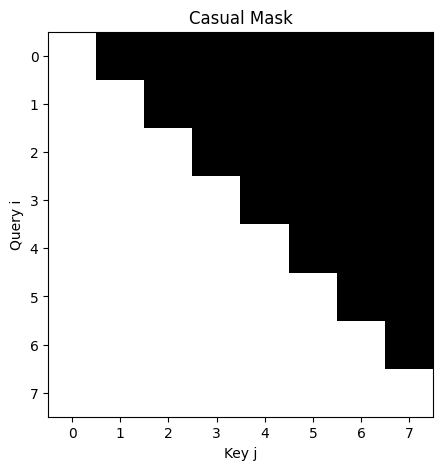

In [20]:
T = 8
casual = torch.tril(torch.ones(T, T, dtype=torch.bool))

plt.figure(figsize=(5, 5))
plt.imshow(casual, cmap="gray")
plt.xlabel("Key j")
plt.ylabel("Query i")
plt.title("Casual Mask")
plt.show()

## 16. Padding mask mathematics

If token ID `0` represents padding:

\[
P_{bj}=
\begin{cases}
1 & x_{bj}\neq PAD\\
0 & x_{bj}=PAD
\end{cases}
\]

We broadcast this over the query dimensions so padded key positions receive:

\[
-\infty
\]

in the attention logits.

Causal and padding masks can be combined with logical AND at the boolean level.

In [21]:
input_ids = torch.tensor([
    [5, 7, 2, 0, 0],
    [3, 4, 8, 1, 9]
])

padding_keys = input_ids != 0
casual = torch.tril(torch.ones(5, 5, dtype=torch.bool))

combined = casual[None, :, :] & padding_keys[:, None, :]

print("padding keys: ")
print(padding_keys)

print("\ncombined mask for sample 0:")
print(combined[0])

padding keys: 
tensor([[ True,  True,  True, False, False],
        [ True,  True,  True,  True,  True]])

combined mask for sample 0:
tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True, False, False]])


# Part IV — Multi-Head Attention Mathematics

## 17. Splitting the model dimension

Suppose:

\[
D=512,\quad H=8
\]

Then:

\[
d_k=\frac{512}{8}=64
\]

Instead of one attention computation over 512 features, we perform 8 attention computations over 64 features.

For a batch:

\[
X\in\mathbb{R}^{B\times T\times D}
\]

After projection and splitting:

\[
Q,K,V\in\mathbb{R}^{B\times H\times T\times d_k}
\]

Each head computes:

\[
head_h =
Attention(Q_h,K_h,V_h)
\]

Then:

\[
MultiHead(Q,K,V)
=
Concat(head_1,\ldots,head_H)W_O
\]

In [22]:
B, T, D, H = 2, 5, 32, 4
d_head = D // H

X = torch.randn(B, T, D)
W = torch.randn(D, 3 * D)

qkv = X @ W
Q, K, V = qkv.chunk(3, dim=-1)

def split_heads(x, num_heads):
    B, T, D = x.shape
    d_head = D // num_heads
    return x.view(B, T, num_heads, d_head).transpose(1, 2)

Qh = split_heads(Q, H)
Kh = split_heads(K, H)
Vh = split_heads(V, H)

print("Q before split:", Q.shape)
print("Q after split :", Qh.shape)
print("Expected      :", (B, H, T, d_head))

Q before split: torch.Size([2, 5, 32])
Q after split : torch.Size([2, 4, 5, 8])
Expected      : (2, 4, 5, 8)


## 18. Multi-head attention computation

For each head:

\[
S_h=\frac{Q_hK_h^T}{\sqrt{d_k}}
\]

\[
A_h=softmax(S_h)
\]

\[
O_h=A_hV_h
\]

Then concatenate:

\[
O=Concat(O_1,\ldots,O_H)
\]

Finally:

\[
Y=OW_O
\]

Notice that the `T × T` interaction occurs independently inside every head.

In [23]:
def manual_multi_head_attention(Q, K, V, num_heads):
    B, T, D = Q.shape
    assert D % num_heads == 0
    dh = D // num_heads

    Q = split_heads(Q, num_heads)
    K = split_heads(K, num_heads)
    V = split_heads(V, num_heads)

    scores = Q @ K.transpose(-2, -1) / math.sqrt(dh)
    weights = F.softmax(scores, dim=-1)

    heads = weights @ V
    merged = heads.transpose(1, 2).contiguous().view(B, T, D)

    return merged, weights


Q0 = torch.randn(2, 5, 32)
K0 = torch.randn(2, 5, 32)
V0 = torch.randn(2, 5, 32)

mha_out, mha_weights = manual_multi_head_attention(Q0, K0, V0, 4)

print("output :", mha_out.shape)
print("weights:", mha_weights.shape)

output : torch.Size([2, 5, 32])
weights: torch.Size([2, 4, 5, 5])


# Part V — Loss Mathematics

## 19. Softmax logits → probability distribution

Suppose the vocabulary has \(V\) tokens.

The language model outputs logits:

\[
z\in\mathbb{R}^{V}
\]

Softmax converts them to:

\[
p_i=\frac{e^{z_i}}{\sum_j e^{z_j}}
\]

The model is therefore producing a probability distribution over the next token.

In [24]:
logits = torch.tensor([1.2, 0.3, 3.0, -0.5])

probs = F.softmax(logits, dim=-1)

print("logits:", logits)
print("probs :", probs)
print("sum   :", probs.sum())

logits: tensor([ 1.2000,  0.3000,  3.0000, -0.5000])
probs : tensor([0.1309, 0.0532, 0.7920, 0.0239])
sum   : tensor(1.0000)


## 20. Cross-entropy / negative log-likelihood

For a single correct target token \(y\):

\[
L=-\log p_y
\]

If the model assigns:

\[
p_y=0.9
\]

then:

\[
L=-\log(0.9)\approx0.105
\]

If:

\[
p_y=0.01
\]

then:

\[
L=-\log(0.01)\approx4.605
\]

So the loss strongly penalizes assigning low probability to the correct token.

In [25]:
for p in [0.9, 0.5, 0.1, 0.01]:
    print(f"p={p:>4}: loss={-math.log(p):.4f}")

p= 0.9: loss=0.1054
p= 0.5: loss=0.6931
p= 0.1: loss=2.3026
p=0.01: loss=4.6052


## 21. Cross-entropy from logits

For a target class \(y\):

\[
L=-\log\left(
\frac{e^{z_y}}
{\sum_j e^{z_j}}
\right)
\]

This can be rearranged as:

\[
L=-z_y+\log\sum_j e^{z_j}
\]

The second term is the **log-sum-exp** term.

In practice, use PyTorch's `cross_entropy`, which is implemented with numerically stable operations.

In [26]:
logits = torch.tensor([[1.0, 2.0, 4.0]])
target = torch.tensor([2])

loss_torch = F.cross_entropy(logits, target)

logsumexp = torch.logsumexp(logits, dim=-1)
loss_manual = -logits[0, target[0]] + logsumexp[0]

print("torch :", loss_torch.item())
print("manual:", loss_manual.item())

torch : 0.1698460429906845
manual: 0.1698460578918457


## 22. Next-token language-model loss

For:

```text
The cat sat
```

the training pairs are:

```text
Input : The   cat
Target: cat   sat
```

For a longer sequence:

\[
x_1,x_2,\ldots,x_T
\]

the autoregressive objective is:

\[
L=
-\sum_{t=1}^{T}
\log P(x_t\mid x_{<t})
\]

Often we average over tokens:

\[
L_{mean}
=
-\frac{1}{T}
\sum_{t=1}^{T}
\log P(x_t\mid x_{<t})
\]

This is the mathematical objective behind next-token language modeling.

In [27]:
B, T, vocab = 2, 5, 10

logits = torch.randn(B, T, vocab)
targets = torch.randint(0, vocab, (B, T))

loss = F.cross_entropy(
    logits.reshape(-1, vocab),
    targets.reshape(-1)
)

print("logits :", logits.shape)
print("targets:", targets.shape)
print("loss   :", loss.item())

logits : torch.Size([2, 5, 10])
targets: torch.Size([2, 5])
loss   : 2.938763380050659


# Part VI — Backpropagation Mathematics

## 23. Why backpropagation?

A Transformer has millions or billions of parameters.

We define a loss:

\[
L(\theta)
\]

where \(\theta\) represents all trainable parameters.

Training needs:

\[
\nabla_\theta L
\]

which tells us how changing every parameter changes the loss.

An optimizer then updates parameters, for example:

\[
\theta_{new}
=
\theta-\eta\nabla_\theta L
\]

where \(\eta\) is the learning rate.

In [30]:
theta = torch.tensor(2.0, requires_grad=True)

loss  = (theta - 5) ** 2
loss.backward()


print("theta  :", theta.item())
print("loss   :", loss.item())
print("dL/dθ  :", theta.grad.item())

theta  : 2.0
loss   : 9.0
dL/dθ  : -6.0


## 24. Chain rule

The key mathematical idea behind backpropagation is the chain rule.

If:

\[
x\rightarrow y\rightarrow z
\]

then:

\[
\frac{dz}{dx}
=
\frac{dz}{dy}
\frac{dy}{dx}
\]

For example:

\[
y=x^2
\]

\[
z=3y
\]

Then:

\[
\frac{dz}{dx}
=
\frac{dz}{dy}
\frac{dy}{dx}
=
3(2x)
=
6x
\]

A Transformer is essentially a very large composition of differentiable functions, so the same rule is applied repeatedly.

In [31]:
x = torch.tensor(2.0, requires_grad=True)

y = x ** 2
z = 3 * y

z.backward()

print("x:", x.item())
print("y:", y.item())
print("z:", z.item())
print("dz/dx:", x.grad.item())
print("Expected dz/dx:", 6 * x.item())

x: 2.0
y: 4.0
z: 12.0
dz/dx: 12.0
Expected dz/dx: 12.0


## 25. Gradient of a simple linear layer

Consider:

\[
y=xW
\]

and a scalar loss:

\[
L=f(y)
\]

The gradient must propagate from:

\[
L\rightarrow y\rightarrow W
\]

and:

\[
L\rightarrow y\rightarrow x
\]

PyTorch's autograd computes these derivatives automatically.

In [32]:
x = torch.tensor([[2.0, 3.0]], requires_grad=True)
W = torch.tensor([[1.0], [2.0]], requires_grad=True)

y = x @ W
loss = y.pow(2).sum()
loss.backward()

print("y:", y.item())
print("dL/dx:", x.grad)
print("dL/dW:", W.grad)


y: 8.0
dL/dx: tensor([[16., 32.]])
dL/dW: tensor([[32.],
        [48.]])


## 26. Softmax gradient intuition

For:

\[
p_i=softmax(z_i)
\]

the derivative is:

\[
\frac{\partial p_i}{\partial z_j}
=
p_i(\delta_{ij}-p_j)
\]

where:

\[
\delta_{ij}=
\begin{cases}
1&i=j\\
0&i\neq j
\end{cases}
\]

This means changing one logit affects **all** probabilities because they share the normalization denominator.

For cross-entropy with softmax, a beautiful simplification occurs:

\[
\boxed{
\frac{\partial L}{\partial z_i}=p_i-y_i
}
\]

where \(y_i\) is the one-hot target.

In [33]:
logits = torch.tensor([1.0, 2.0, 4.0], requires_grad=True)
target = torch.tensor([2])

loss = F.cross_entropy(logits.unsqueeze(0), target)
loss.backward()

probs = F.softmax(logits.detach(), dim=-1)
one_hot = F.one_hot(target, num_classes=3).float().squeeze()

print("probabilities:", probs)
print("gradient     :", logits.grad)
print("p - y        :", probs - one_hot)
print("same?        :", torch.allclose(logits.grad, probs - one_hot))

probabilities: tensor([0.0420, 0.1142, 0.8438])
gradient     : tensor([ 0.0420,  0.1142, -0.1562])
p - y        : tensor([ 0.0420,  0.1142, -0.1562])
same?        : True


# Part VII — Backpropagation Through Attention

## 27. Attention as a computational graph

Write attention as separate operations:

\[
Q=XW_Q
\]

\[
K=XW_K
\]

\[
S=\frac{QK^T}{\sqrt{d_k}}
\]

\[
A=softmax(S)
\]

\[
O=AV
\]

Suppose the final loss is:

\[
L=L(O)
\]

Backpropagation travels in reverse:

```text
L
↑
O = A V
↑       ↑
A       V
↑
S = QKᵀ / √dk
↑    ↑
Q    K
↑    ↑
XWQ  XWK
```

This is the mathematical reason the attention projections \(W_Q,W_K,W_V\) learn during training.

In [34]:
class TinyAttentionForGradients(torch.nn.Module):
    def __init__(self, d_model, d_head):
        super().__init__()
        self.Wq = torch.nn.Parameter(torch.randn(d_model, d_head) * 0.1)
        self.Wk = torch.nn.Parameter(torch.randn(d_model, d_head) * 0.1)
        self.Wv = torch.nn.Parameter(torch.randn(d_model, d_head) * 0.1)

    def forward(self, X):
        Q = X @ self.Wq
        K = X @ self.Wk
        V = X @ self.Wv

        scores = Q @ K.transpose(-2, -1) / math.sqrt(K.size(-1))
        A = F.softmax(scores, dim=-1)
        O = A @ V

        return O, (Q, K, V, scores, A)


X = torch.randn(1, 4, 8, requires_grad=True)
attn_model = TinyAttentionForGradients(8, 4)

O, intermediates = attn_model(X)
loss = O.pow(2).mean()
loss.backward()

print("loss:", loss.item())
print("dL/dX shape :", X.grad.shape)
print("dL/dWq shape:", attn_model.Wq.grad.shape)
print("dL/dWk shape:", attn_model.Wk.grad.shape)
print("dL/dWv shape:", attn_model.Wv.grad.shape)

loss: 0.00993383303284645
dL/dX shape : torch.Size([1, 4, 8])
dL/dWq shape: torch.Size([8, 4])
dL/dWk shape: torch.Size([8, 4])
dL/dWv shape: torch.Size([8, 4])


## 28. Inspect gradient magnitudes

A useful debugging concept is the magnitude of gradients.

If gradients become extremely small:

\[
\|\nabla L\|\approx0
\]

learning can become slow.

If gradients become extremely large, optimization can become unstable.

Modern Transformer design choices such as normalization, initialization and residual pathways are closely connected to maintaining useful gradient flow.

In [35]:
for name, param in attn_model.named_parameters():
    if param.grad is not None:
        print(f"{name} grad norm: {param.grad.norm().item():.6f}")

Wq grad norm: 0.005084
Wk grad norm: 0.003034
Wv grad norm: 0.126951


# Part VIII — Transformer Parameter Mathematics

## 29. Parameter count of a linear layer

For:

\[
Y=XW+b
\]

where:

\[
W\in\mathbb{R}^{D_{in}\times D_{out}}
\]

the number of weights is:

\[
D_{in}D_{out}
\]

and biases add:

\[
D_{out}
\]

Therefore:

\[
\boxed{
N=D_{in}D_{out}+D_{out}
}
\]

This simple formula is enough to estimate many Transformer parameters.

In [36]:
def linear_paragms(d_in, d_out, bias=True):
    return d_in * d_out + (d_out if bias else 0)

print("64 -> 256 (with bias):", linear_paragms(64, 256))
print("64 -> 256 (without bias):", linear_paragms(64, 256, bias=False))

print("256 -> 64 (with bias):", linear_paragms(256, 64))
print("256 -> 64 (without bias):", linear_paragms(256, 64, bias=False))


64 -> 256 (with bias): 16640
64 -> 256 (without bias): 16384
256 -> 64 (with bias): 16448
256 -> 64 (without bias): 16384


## 30. Approximate parameters in attention projections

A standard multi-head attention module still has four main projections:

\[
W_Q,\ W_K,\ W_V,\ W_O
\]

If all are:

\[
D\times D
\]

then approximately:

\[
4D^2
\]

weights, ignoring biases.

Notice something important:

> Splitting attention into multiple heads does **not** by itself reduce the total projection parameter count when the total model dimension remains \(D\).

In [37]:
def attention_parameter_estimate(d_model):
    return 4 * d_model * d_model

for D in [256, 512, 1024]:
    print(f"d_model={D:4d} | estimated parameters: {attention_parameter_estimate(D)}")


d_model= 256 | estimated parameters: 262144
d_model= 512 | estimated parameters: 1048576
d_model=1024 | estimated parameters: 4194304


## 31. FFN parameter count

For a standard FFN:

\[
D\rightarrow D_{ff}\rightarrow D
\]

the weight count is approximately:

\[
DD_{ff}+D_{ff}D
=
2DD_{ff}
\]

If:

\[
D_{ff}=4D
\]

then:

\[
2D(4D)=8D^2
\]

So a standard FFN can contain roughly **twice as many weights as the four attention projections combined**.

This is one reason the FFN is a major contributor to Transformer parameter count.

In [38]:
def ffn_parameter_estimate(d_model, d_ff):
    return 2 * d_model * d_ff

for D in [256, 512, 1024]:
    print(f"D={D}, d_ff=4D: ~{ffn_parameter_estimate(D, 4*D):,} FFN weights")

D=256, d_ff=4D: ~524,288 FFN weights
D=512, d_ff=4D: ~2,097,152 FFN weights
D=1024, d_ff=4D: ~8,388,608 FFN weights


# Part IX — Complexity Mathematics

## 32. Why attention is \(O(T^2)\)

The expensive part is:

\[
QK^T
\]

For:

\[
Q\in\mathbb{R}^{T\times d_k}
\]

and:

\[
K^T\in\mathbb{R}^{d_k\times T}
\]

the result is:

\[
T\times T
\]

There are \(T^2\) pairwise interactions.

So the attention matrix alone scales as:

\[
\boxed{O(T^2)}
\]

This is the fundamental reason long-context attention becomes expensive.

In [39]:
for T in [128, 512, 1024, 2048, 4096, 8192]:
    print(f"T={T:5d} -> T²={T*T:>12,}")

T=  128 -> T²=      16,384
T=  512 -> T²=     262,144
T= 1024 -> T²=   1,048,576
T= 2048 -> T²=   4,194,304
T= 4096 -> T²=  16,777,216
T= 8192 -> T²=  67,108,864


## 33. Memory intuition

A full attention matrix for:

\[
B\times H\times T\times T
\]

contains:

\[
BHT^2
\]

values.

For example:

\[
B=4,\ H=16,\ T=4096
\]

gives:

\[
4\times16\times4096^2
\]

attention values.

This quadratic term is why techniques such as FlashAttention, sparse attention, local attention and other efficient-attention methods matter.

In [40]:
B, H, T = 4, 16, 4096
attention_elements = B * H * T * T
fp16_gb = attention_elements * 2 / (1024**3)

print("attention elements:", f"{attention_elements:,}")
print("FP16 raw storage :", f"{fp16_gb:.2f} GiB")

attention elements: 1,073,741,824
FP16 raw storage : 2.00 GiB


# Part X — Complete Mathematical Forward Pass

## 34. Put everything together

For a single Transformer self-attention layer:

### Step 1 — input

\[
X\in\mathbb{R}^{B\times T\times D}
\]

### Step 2 — projections

\[
Q=XW_Q,\quad K=XW_K,\quad V=XW_V
\]

### Step 3 — similarity

\[
S=QK^T
\]

### Step 4 — scale

\[
\tilde S=\frac{S}{\sqrt{d_k}}
\]

### Step 5 — mask

\[
\tilde S_{masked}
=
\tilde S + M
\]

### Step 6 — normalize scores

\[
A=softmax(\tilde S_{masked})
\]

### Step 7 — retrieve information

\[
O=AV
\]

### Step 8 — output projection

\[
Y=OW_O
\]

Then the Transformer block adds residual connections, normalization and an FFN.

That is the mathematical core.

In [41]:
def complete_attention_forward(X, Wq, Wk, Wv, Wo, mask=None):
    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv

    scores = Q @ K.transpose(-2, -1)
    scores = scores / math.sqrt(Q.size(-1))

    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))

    A = F.softmax(scores, dim=-1)
    O = A @ V
    Y = O @ Wo

    return Y, {
        "Q": Q,
        "K": K,
        "V": V,
        "scores": scores,
        "attention": A,
        "head_output": O,
        "output": Y,
    }


B, T, D = 2, 6, 16

X = torch.randn(B, T, D)
Wq = torch.randn(D, D) / math.sqrt(D)
Wk = torch.randn(D, D) / math.sqrt(D)
Wv = torch.randn(D, D) / math.sqrt(D)
Wo = torch.randn(D, D) / math.sqrt(D)

mask = torch.tril(torch.ones(T, T, dtype=torch.bool))[None, :, :]

Y, trace = complete_attention_forward(X, Wq, Wk, Wv, Wo, mask)

for name, tensor in trace.items():
    print(f"{name:>12}: {tuple(tensor.shape)}")

           Q: (2, 6, 16)
           K: (2, 6, 16)
           V: (2, 6, 16)
      scores: (2, 6, 6)
   attention: (2, 6, 6)
 head_output: (2, 6, 16)
      output: (2, 6, 16)


## 35. Verify the causal property numerically

After causal masking:

\[
A_{ij}=0\quad\text{for }j>i
\]

Let's verify that the upper-triangular attention weights are essentially zero.

In [42]:
A = trace["attention"]

upper = torch.triu(A, diagonal=1)

print("Maximum future-token attention weight:",
      upper.abs().max().item())

Maximum future-token attention weight: 0.0


# 36. Mathematical summary — what to truly understand

### Linear algebra

\[
Q=XW_Q,\quad K=XW_K,\quad V=XW_V
\]

### Similarity

\[
S=QK^T
\]

### Scaling

\[
\tilde S=\frac{S}{\sqrt{d_k}}
\]

### Masking

\[
\tilde S_{ij}\leftarrow-\infty
\]

for forbidden positions.

### Probability distribution

\[
A=softmax(\tilde S)
\]

### Information aggregation

\[
O=AV
\]

### Multi-head attention

\[
MultiHead(Q,K,V)
=
Concat(head_1,\ldots,head_H)W_O
\]

### Language-model loss

\[
L=-\sum_t\log P(x_t|x_{<t})
\]

### Parameter update

\[
\theta\leftarrow\theta-\eta\nabla_\theta L
\]

### Attention complexity

\[
O(T^2)
\]

These equations form the mathematical backbone of Transformer models.